In [1]:
import matplotlib.pyplot as plt
import os
import sys
sys.path.append('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/scripts')

sys.path.append('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/scripts/mge_classv2')
from mge_gen3 import MGEFitter
from astropy.io import fits
import numpy as np
import mgefit as mge
from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

In [7]:
# load the data
study_path = '/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/ppxf_nirspec/antoine_wicked_powerbin_sn300_lsf_degree_study'

# load the kinematics cubes that are in each folder and store them in a dictionary
name_kin = 'sombrero_nirspec_1150_p1293_g235_wicked_phoenix_powerbin_lsf_sn300_kinematics.csv'
kinematics_cubes = {}
for deg in ['00', '05', '10']:
    for mdeg in ['00', '05', '10']:
        cube_path = os.path.join(study_path, f'deg{deg}_mdeg{mdeg}', name_kin)
        if os.path.exists(cube_path):
            kinematics_cubes[(deg, mdeg)] = Table.read(cube_path, format='csv', delimiter=';')
        else:
            print(f'File not found: {cube_path}')

In [8]:
kinematics_cubes.keys()

dict_keys([('00', '00'), ('00', '05'), ('00', '10'), ('05', '00'), ('05', '05'), ('05', '10'), ('10', '00'), ('10', '05'), ('10', '10')])

# Plot data

In [13]:
    
def plot_map(x, y, values, cmap='RdBu_r', cbar_label='Value',
              ax=None, show=True, vmin=None, vmax=None, cbar=True):
    # takes the xy and values and plots as an image with a colorbar
    # create a grid of x and y values
    xi = np.linspace(np.min(x), np.max(x), 100)
    yi = np.linspace(np.min(y), np.max(y), 100)
    xi, yi = np.meshgrid(xi, yi)
    # interpolate the values onto the grid
    zi = griddata((x, y), values, (xi, yi), method='cubic')
    # plot the image
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))
    im = ax.imshow(zi, extent=(np.min(x), np.max(x), np.min(y), np.max(y)),
                    origin='lower', cmap=cmap, vmin=vmin, vmax=vmax)
    if cbar:
        plt.colorbar(im, ax=ax, label=cbar_label, pad=0.01)
    ax.set_xlabel('X (arcsec)')
    ax.set_ylabel('Y (arcsec)')
    if show:
        plt.show()
    
def rotate(x, y, angle_deg):
    angle_rad = np.radians(angle_deg)
    x_rot = x * np.cos(angle_rad) - y * np.sin(angle_rad)
    y_rot = x * np.sin(angle_rad) + y * np.cos(angle_rad)
    return x_rot, y_rot
# kin_table["X_rot"], kin_table["Y_rot"] = rotate(kin_table["X"],
#                                                  kin_table["Y"], -18)

# rotate the coordinates by -18 degrees to align with the major axis of the galaxy
for key in kinematics_cubes.keys():
    kinematics_cubes[key]["X_rot"], kinematics_cubes[key]["Y_rot"] = rotate(kinematics_cubes[key]["X"],
                                                                             kinematics_cubes[key]["Y"], -18)
    
# substract the systemic velocity from the velocity map
for key in kinematics_cubes.keys():
    kinematics_cubes[key]["LOSV_sub"] = kinematics_cubes[key]["LOSV"] - np.median(kinematics_cubes[key]["LOSV"])

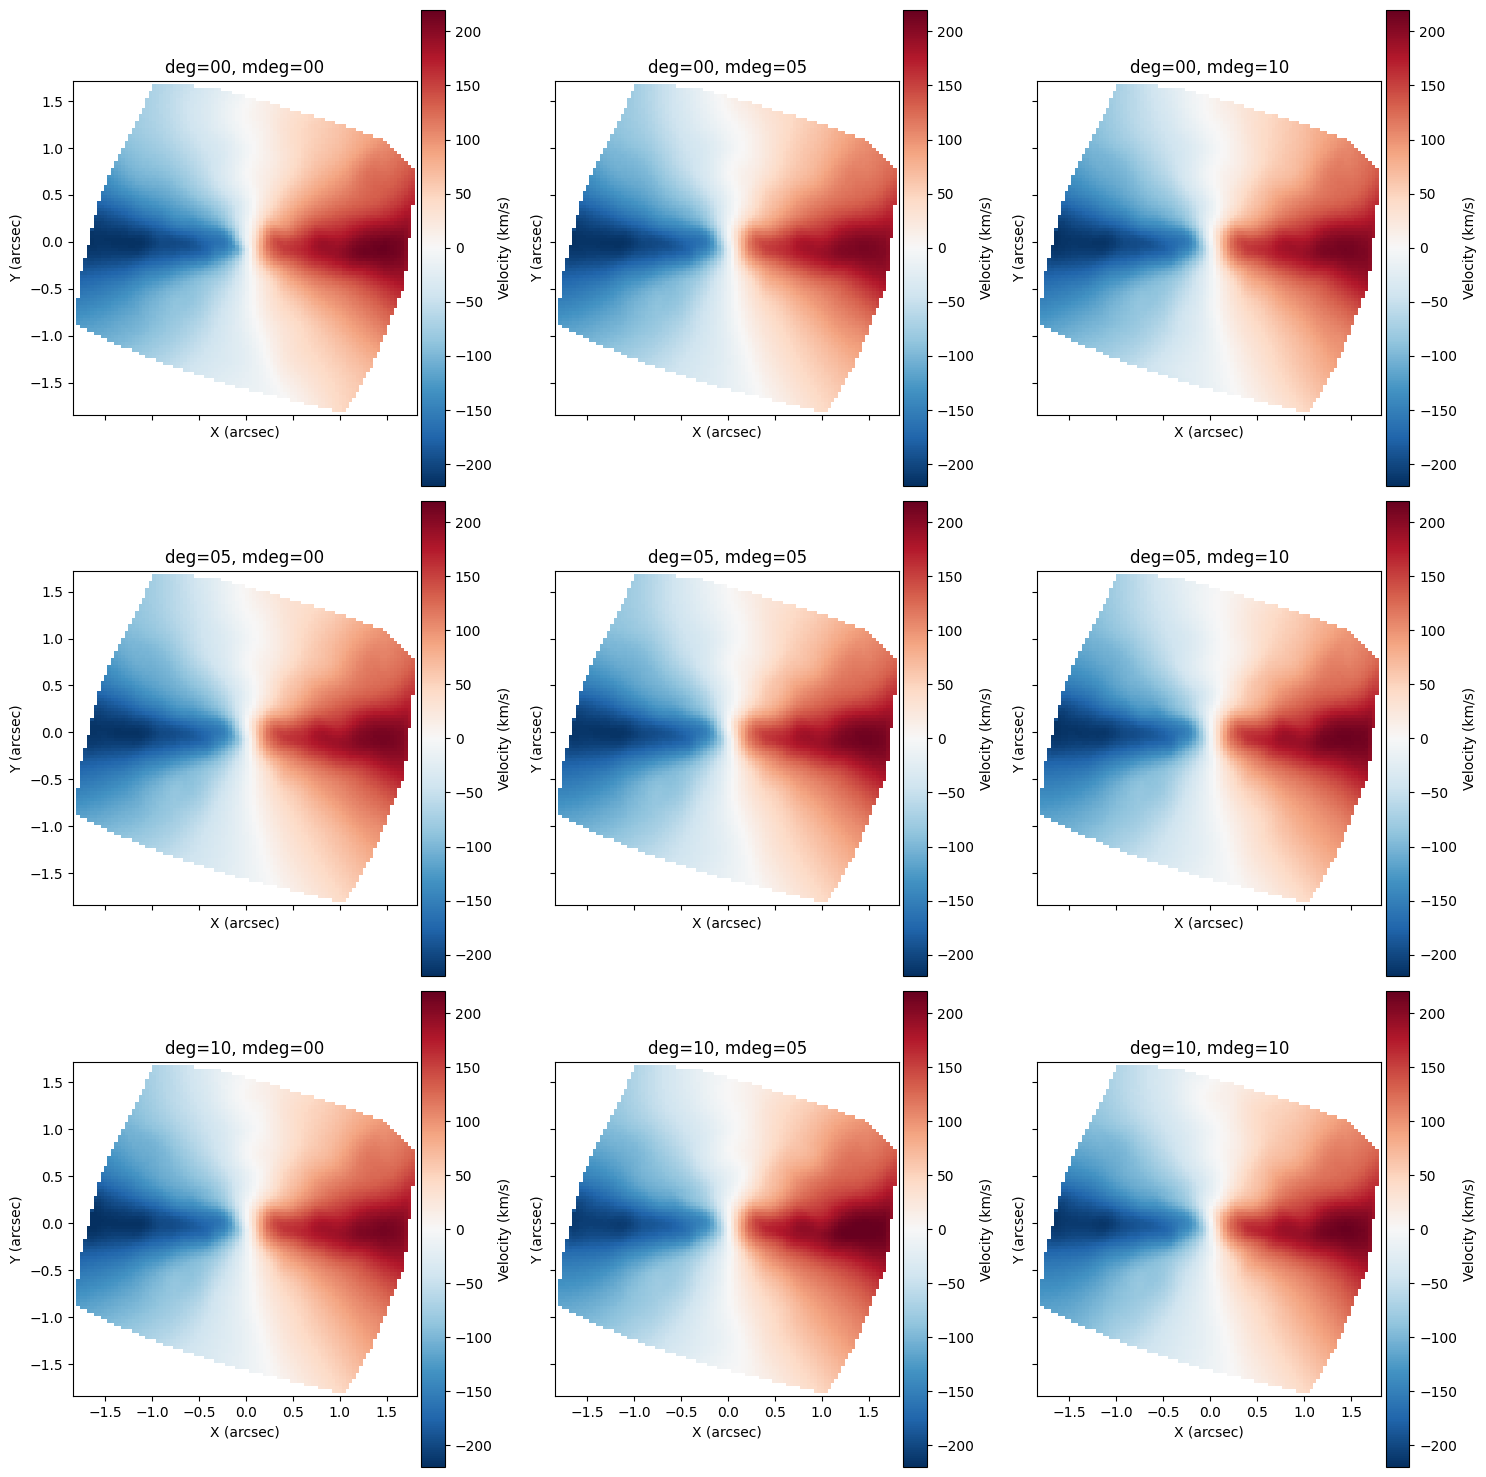

In [15]:
# plot the velocity along the major axis for each degree combination
fig, axes = plt.subplots(3, 3, figsize=(15, 15), sharex=True, sharey=True)
for i, deg in enumerate(['00', '05', '10']):
    for j, mdeg in enumerate(['00', '05', '10']):
        key = (deg, mdeg)
        if key in kinematics_cubes:
            kin_table = kinematics_cubes[key]
            plot_map(kin_table["X_rot"], kin_table["Y_rot"], kin_table["LOSV_sub"],
                     ax=axes[i, j], show=False, vmin=-220, vmax=220,
                     cbar_label='Velocity (km/s)')
            axes[i, j].set_title(f'deg={deg}, mdeg={mdeg}')
plt.tight_layout()
plt.show()

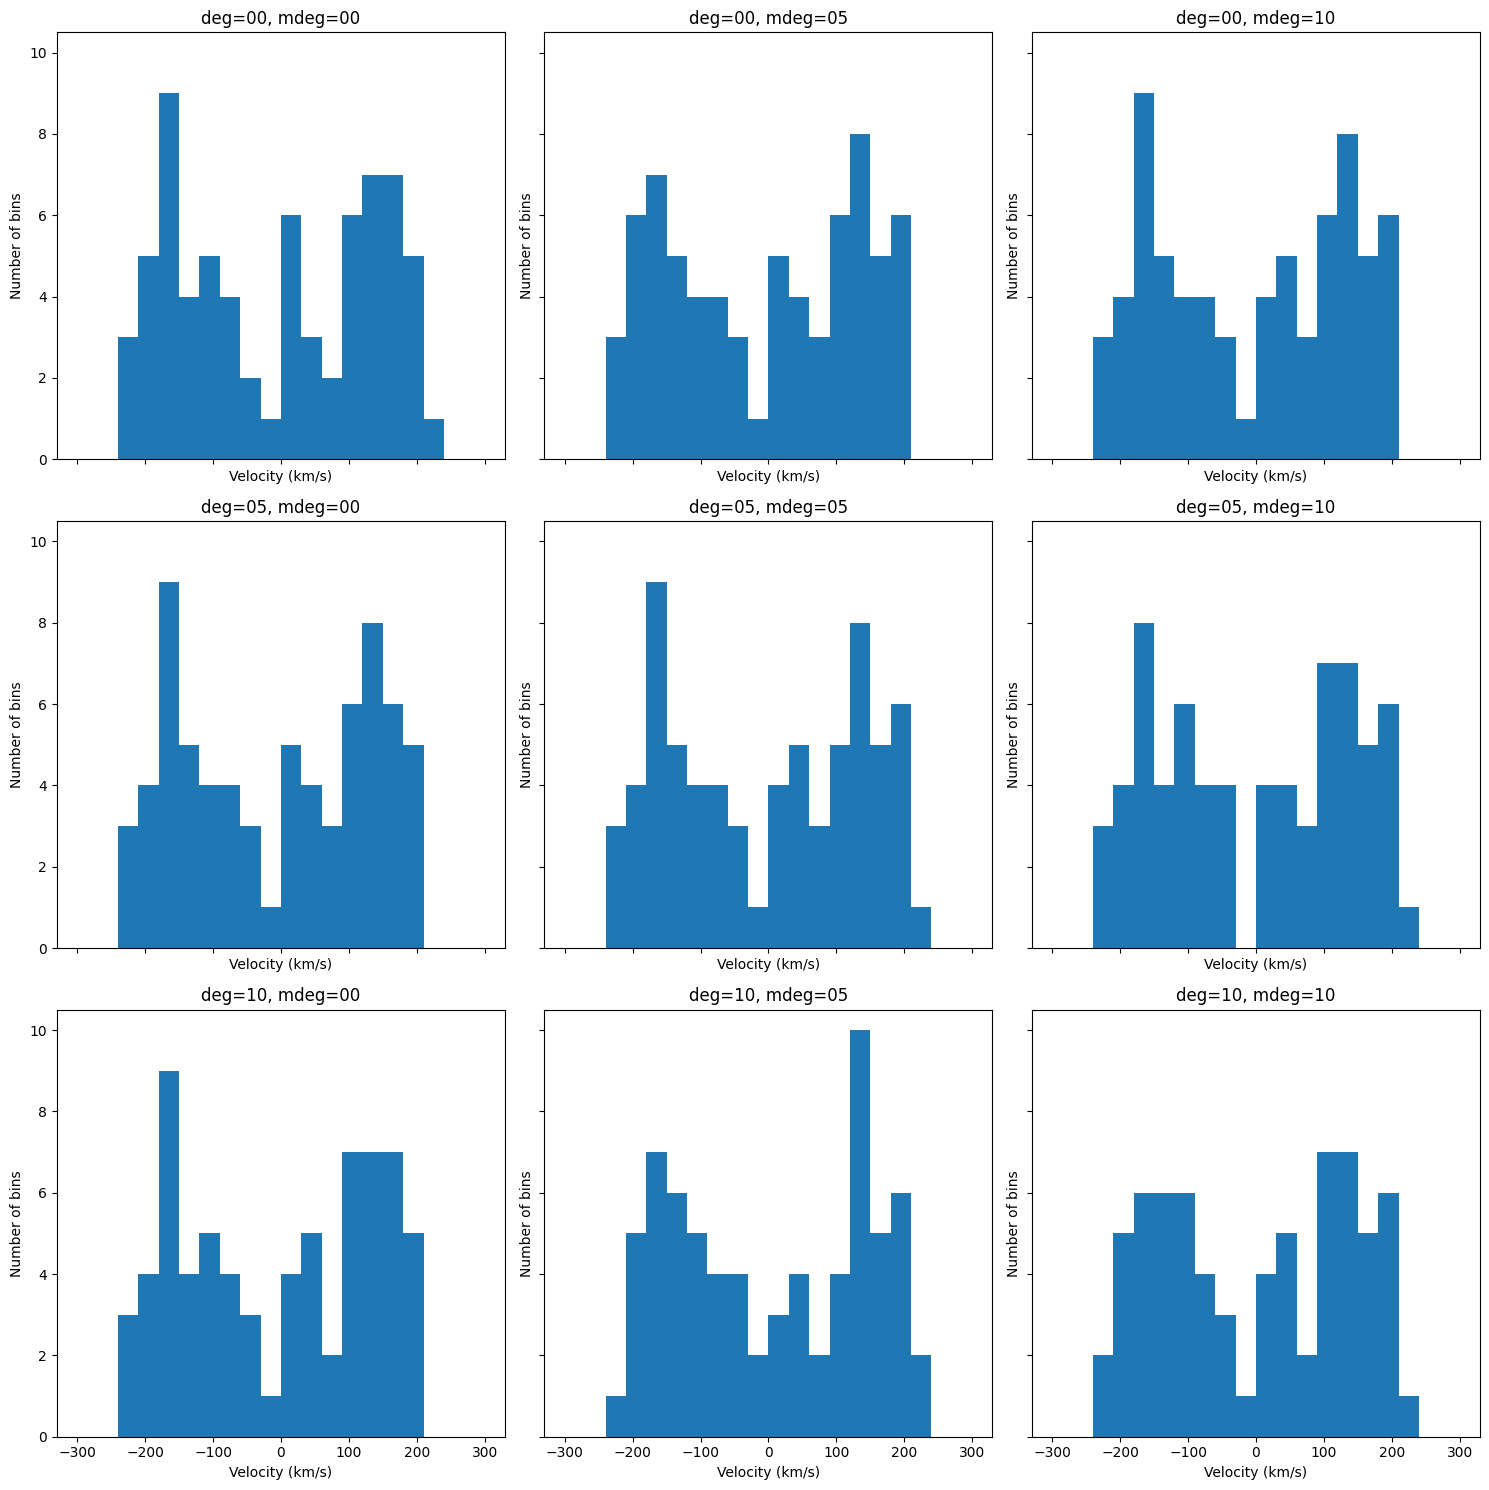

In [16]:
# plot histograms of the velocity distribution at |y| < 0.5 arcsec for each degree combination
fig, axes = plt.subplots(3, 3, figsize=(15, 15), sharex=True, sharey=True)
for i, deg in enumerate(['00', '05', '10']):
    for j, mdeg in enumerate(['00', '05', '10']):
        key = (deg, mdeg)
        if key in kinematics_cubes:
            kin_table = kinematics_cubes[key]
            mask = np.abs(kin_table["Y_rot"]) < 0.5
            axes[i, j].hist(kin_table["LOSV_sub"][mask], bins=20, range=(-300, 300))
            axes[i, j].set_title(f'deg={deg}, mdeg={mdeg}')
            axes[i, j].set_xlabel('Velocity (km/s)')
            axes[i, j].set_ylabel('Number of bins')
plt.tight_layout()
plt.show()

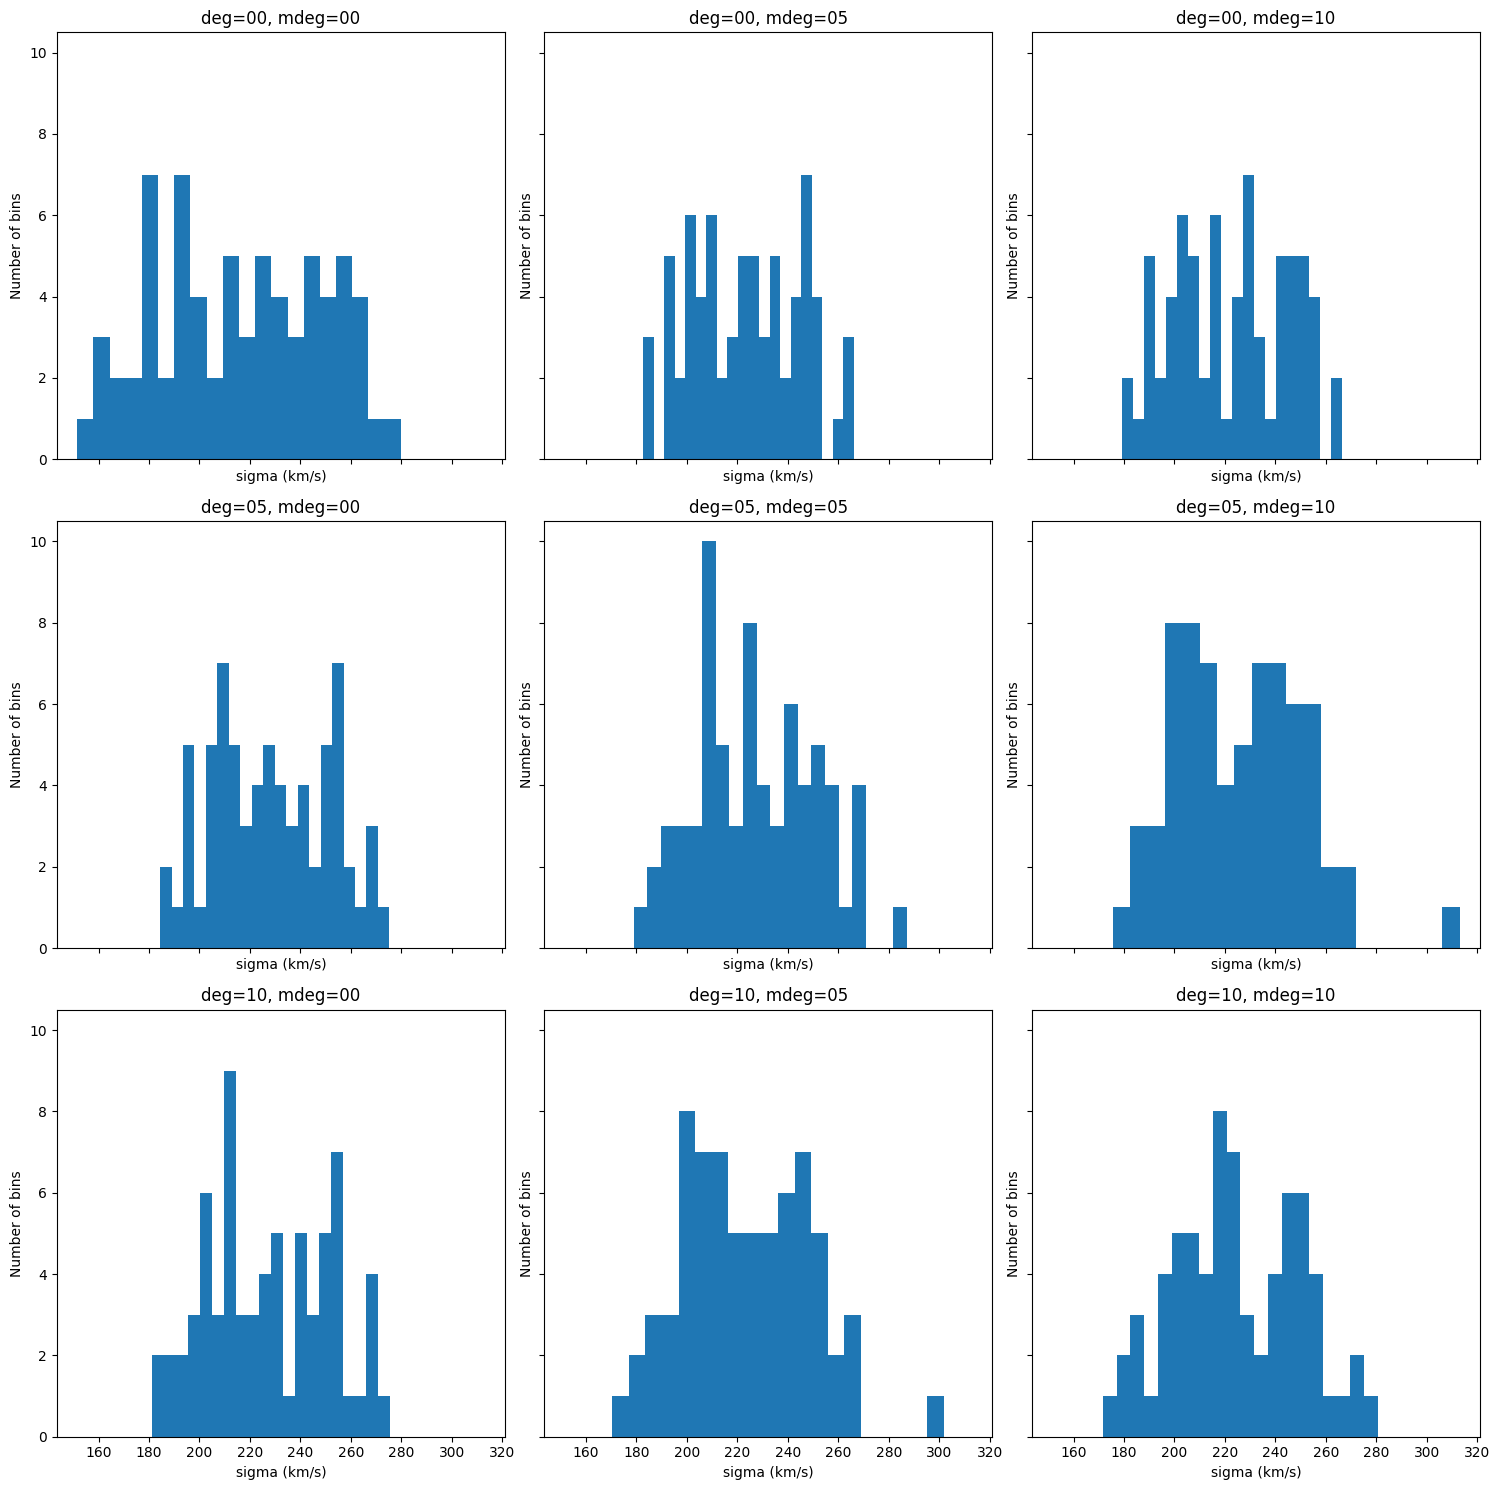

In [18]:
# plot histograms of the velocity distribution at |y| < 0.5 arcsec for each degree combination
fig, axes = plt.subplots(3, 3, figsize=(15, 15), sharex=True, sharey=True)
for i, deg in enumerate(['00', '05', '10']):
    for j, mdeg in enumerate(['00', '05', '10']):
        key = (deg, mdeg)
        if key in kinematics_cubes:
            kin_table = kinematics_cubes[key]
            mask = np.abs(kin_table["Y_rot"]) < 0.5
            axes[i, j].hist(kin_table["sigma"][mask], bins=20)
            axes[i, j].set_title(f'deg={deg}, mdeg={mdeg}')
            axes[i, j].set_xlabel('sigma (km/s)')
            axes[i, j].set_ylabel('Number of bins')
plt.tight_layout()
plt.show()

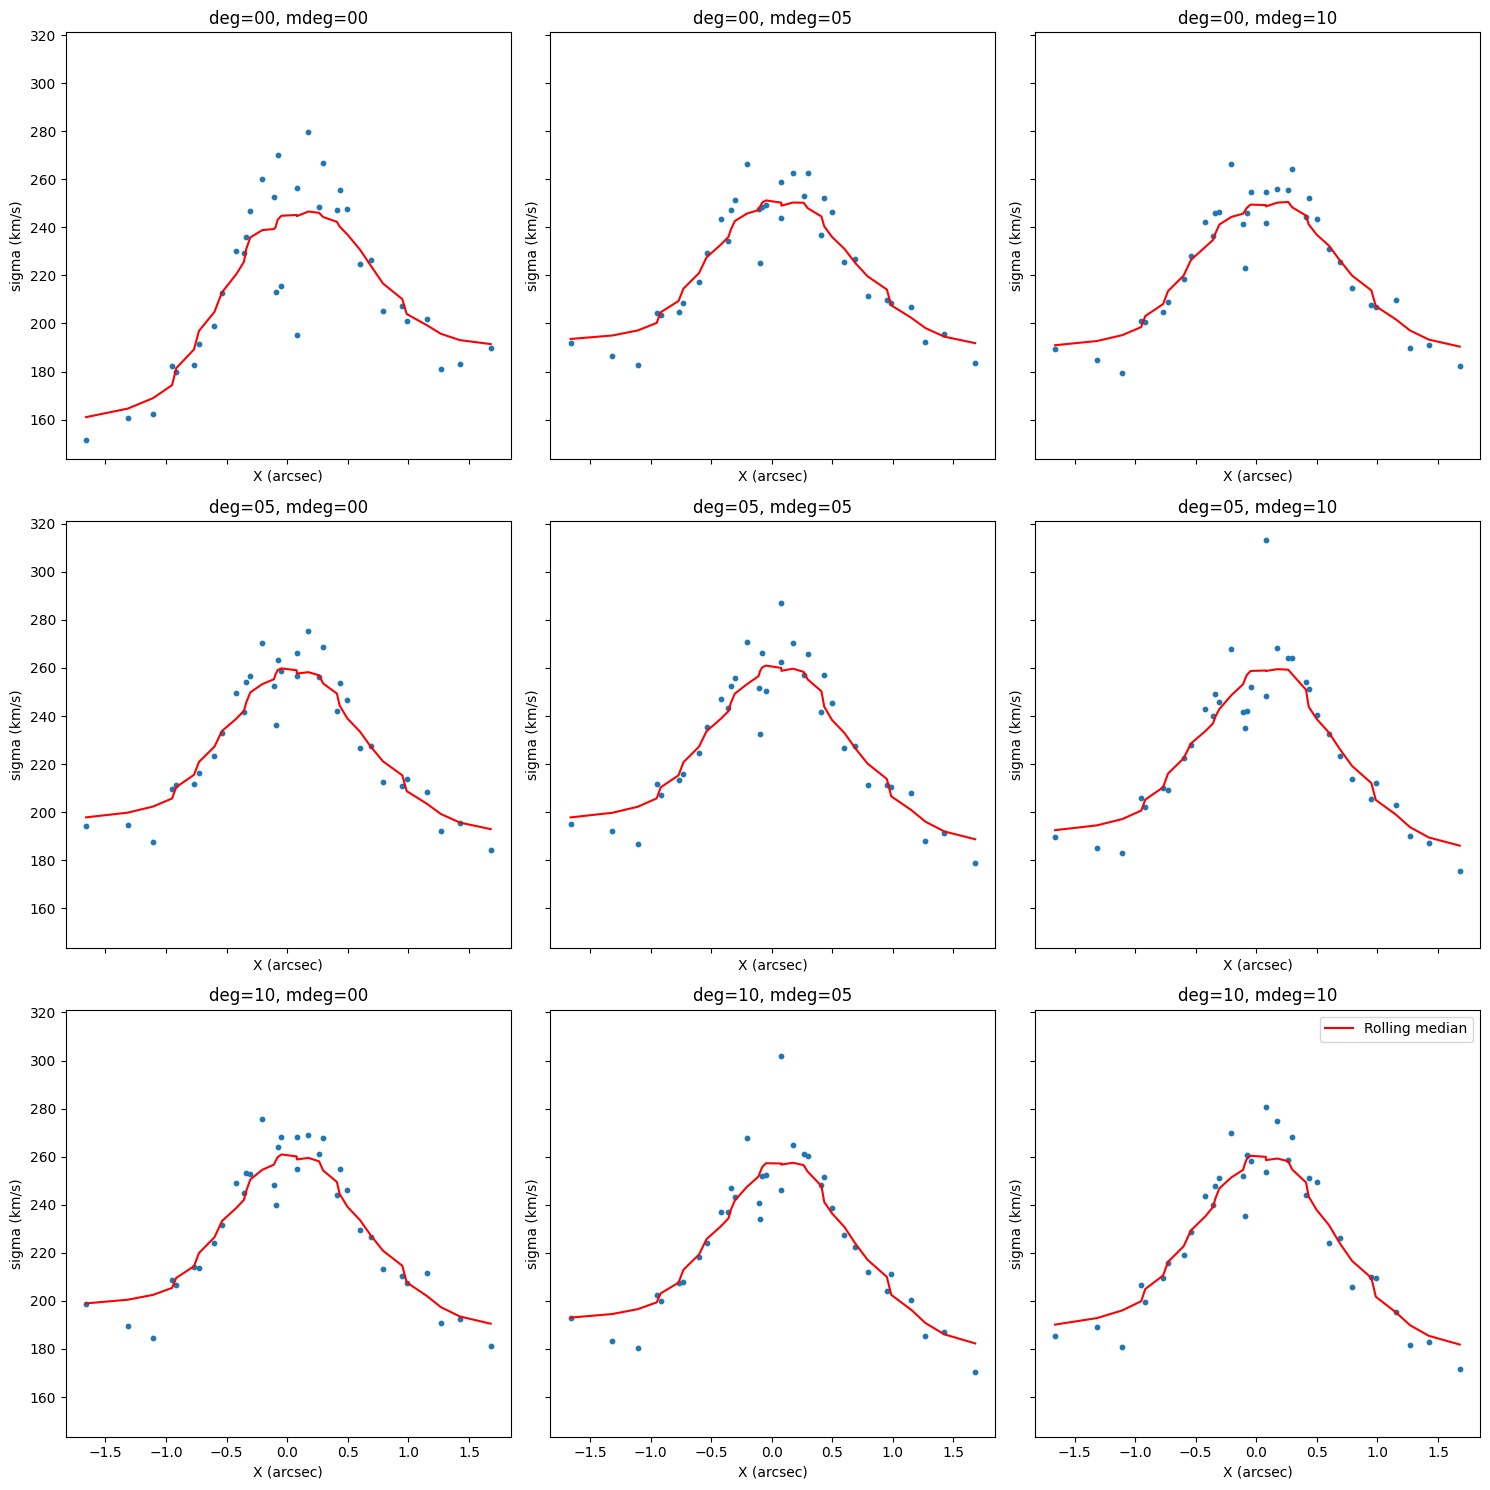

In [27]:
# plot the sigma as a function of X for |y| < 0.5 arcsec for each degree combination
fig, axes = plt.subplots(3, 3, figsize=(15, 15), sharex=True, sharey=True)
for i, deg in enumerate(['00', '05', '10']):
    for j, mdeg in enumerate(['00', '05', '10']):
        key = (deg, mdeg)
        if key in kinematics_cubes:
            kin_table = kinematics_cubes[key]
            mask = np.abs(kin_table["Y_rot"]) < 0.2
            axes[i, j].scatter(kin_table["X_rot"][mask], kin_table["sigma"][mask], s=10)
            # add a rolling median to the plot
            from astropy.convolution import convolve, Box1DKernel
            x_sorted = np.sort(kin_table["X_rot"][mask])
            sigma_sorted = kin_table["sigma"][mask][np.argsort(kin_table["X_rot"][mask])]
            sigma_smooth = convolve(sigma_sorted, Box1DKernel(10), boundary='extend')
            axes[i, j].plot(x_sorted, sigma_smooth, color='red', label='Rolling median')

            
            axes[i, j].set_title(f'deg={deg}, mdeg={mdeg}')
            axes[i, j].set_xlabel('X (arcsec)')
            axes[i, j].set_ylabel('sigma (km/s)')
plt.legend()
plt.tight_layout()
plt.show()